In [ ]:

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib import cm
from sklearn.cluster import KMeans, SpectralClustering
from sklearn.metrics import silhouette_samples, silhouette_score

In [ ]:
SEED = 22938578

In [7]:
df_diagnosis = pd.read_csv("/static/PMBB/PMBB-Release-2026-4.0/Phenotype/4.0/PMBB-Release-2026-4.0_phenotype_conditions_phecode_12.txt", sep="\t")

In [11]:
# Select COPD diagnoses based on PheCodes
df_diagnosis = df_diagnosis[df_diagnosis["condition_source_value"].astype(str).str.contains("496")]
n_copd = df_diagnosis["person_id"].unique().shape[0]
print(f"Number of unique COPD patients in PMBB v4: {n_copd}")

Number of unique COPD patients in PMBB v4: 10393


In [12]:
df_icd = pd.read_csv("/static/PMBB/PMBB-Release-2026-4.0/Phenotype/4.0/PMBB-Release-2026-4.0_phenotype_conditions_icd10.txt", sep="\t")
df_icd = df_icd[df_icd["condition_source_value"].astype(str).str.contains("J44")]
n_copd_icd = df_icd["person_id"].unique().shape[0]
print(f"Number of unique COPD patients in PMBB v4: {n_copd_icd}")

Number of unique COPD patients in PMBB v4: 7523


In [13]:
df_pgs = pd.read_csv("data/pgsc-calc/partitioned/PMBB/score/PMBB_pgs.txt.gz", sep="\t")
df_pgs = df_pgs.pivot(index="IID", columns="PGS", values="Z_norm2")
df_pgs = df_pgs[df_pgs.index.isin(df_diagnosis["person_id"].unique())]

## Clustering Based on Adult Lineage Markers

In [ ]:
range_n_clusters = list(range(2,12))

def plot_silhouette_and_clusters(df, SEED: int, range_n_clusters = list(range(2,12))):
    for n_clusters in range_n_clusters:
        # Create a subplot with 1 row and 2 columns
        fig, (ax1, ax2) = plt.subplots(1, 2)
        fig.set_size_inches(18, 7)

        # The 1st subplot is the silhouette plot
        ax1.set_xlim([-1, 1])
        # The (n_clusters+1)*10 is for inserting blank space between silhouette
        # plots of individual clusters, to demarcate them clearly.
        ax1.set_ylim([0, len(df) + (n_clusters + 1) * 10])
        
        # Create clusterer
        clusterer = KMeans(n_clusters=n_clusters, n_init=100, random_state=SEED)
        cluster_labels = clusterer.fit_predict(df)
        silhouette_avg = silhouette_score(df, cluster_labels)
        print(f"For n_clusters = {n_clusters} the average silhouette_score is : {silhouette_avg}")

        # Compute the silhouette scores for each sample
        sample_silhouette_values = silhouette_samples(df, cluster_labels)

        y_lower = 10
        for i in range(n_clusters):
            # Aggregate the silhouette scores for samples belonging to
            # cluster i, and sort them
            ith_cluster_silhouette_values = \
                sample_silhouette_values[cluster_labels == i]

            ith_cluster_silhouette_values.sort()

            size_cluster_i = ith_cluster_silhouette_values.shape[0]
            y_upper = y_lower + size_cluster_i

            color = cm.nipy_spectral(float(i) / n_clusters)
            ax1.fill_betweenx(np.arange(y_lower, y_upper),
                            0, ith_cluster_silhouette_values,
                            facecolor=color, edgecolor=color, alpha=0.7)

            # Label the silhouette plots with their cluster numbers at the middle
            ax1.text(-0.05, y_lower + 0.5 * size_cluster_i, str(i))

            # Compute the new y_lower for next plot
            y_lower = y_upper + 10  # 10 for the 0 samples

        ax1.set_title("The silhouette plot for the various clusters.")
        ax1.set_xlabel("The silhouette coefficient values")
        ax1.set_ylabel("Cluster label")

        # The vertical line for average silhouette score of all the values
        ax1.axvline(x=silhouette_avg, color="red", linestyle="--")

        ax1.set_yticks([])  # Clear the yaxis labels / ticks
        ax1.set_xticks([-1, -0.8, -0.6, -0.4, -0.2, 0, 0.2, 0.4, 0.6, 0.8, 1])

        # 2nd Plot showing the actual clusters formed
        colors = cm.nipy_spectral(cluster_labels.astype(float) / n_clusters)
        ax2.scatter(df.iloc[:, 0], df.iloc[:, 1], marker='.', s=30, lw=0, alpha=0.7, c=colors, edgecolor='k')

        # Labeling the clusters
        centers = clusterer.cluster_centers_
        # Draw white circles at cluster centers
        ax2.scatter(centers[:, 0], centers[:, 1], marker='o',
                    c="white", alpha=1, s=200, edgecolor='k')

        for i, c in enumerate(centers):
            ax2.scatter(c[0], c[1], marker='$%d$' % i, alpha=1,
                        s=50, edgecolor='k')

        ax2.set_title("The visualization of the clustered data.")
        ax2.set_xlabel("Feature space for the 1st feature")
        ax2.set_ylabel("Feature space for the 2nd feature")

        plt.suptitle((f"Silhouette analysis for KMeans clustering on sample data with n_clusters = {n_clusters}"),
                    fontsize=14, fontweight='bold')

        plt.show()

In [25]:
df_lineage = df_pgs[
    ["copd_epithelium", 
    "copd_endothelium", 
    "copd_mesenchyme", 
    "copd_myeloid", 
    "copd_lymphoid"]
    ]

For n_clusters = 2 the average silhouette_score is : 0.14544783314364507


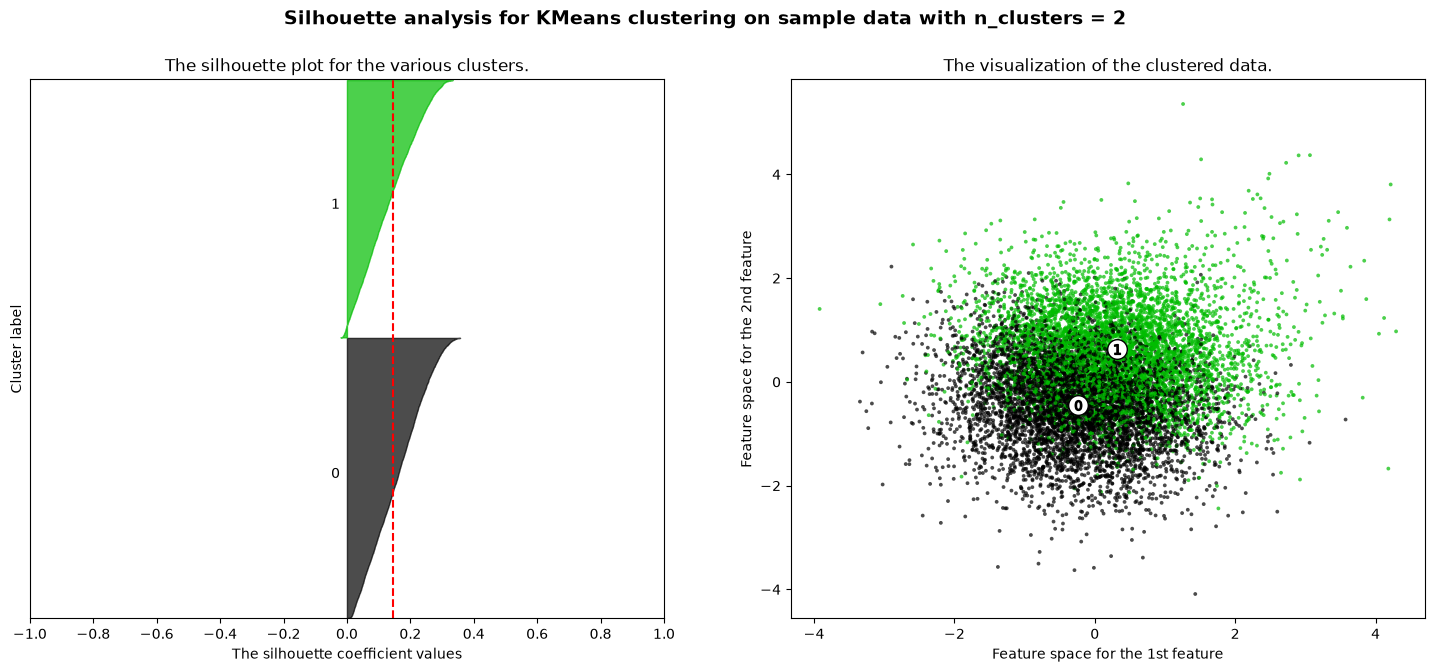

For n_clusters = 3 the average silhouette_score is : 0.13124166041119903


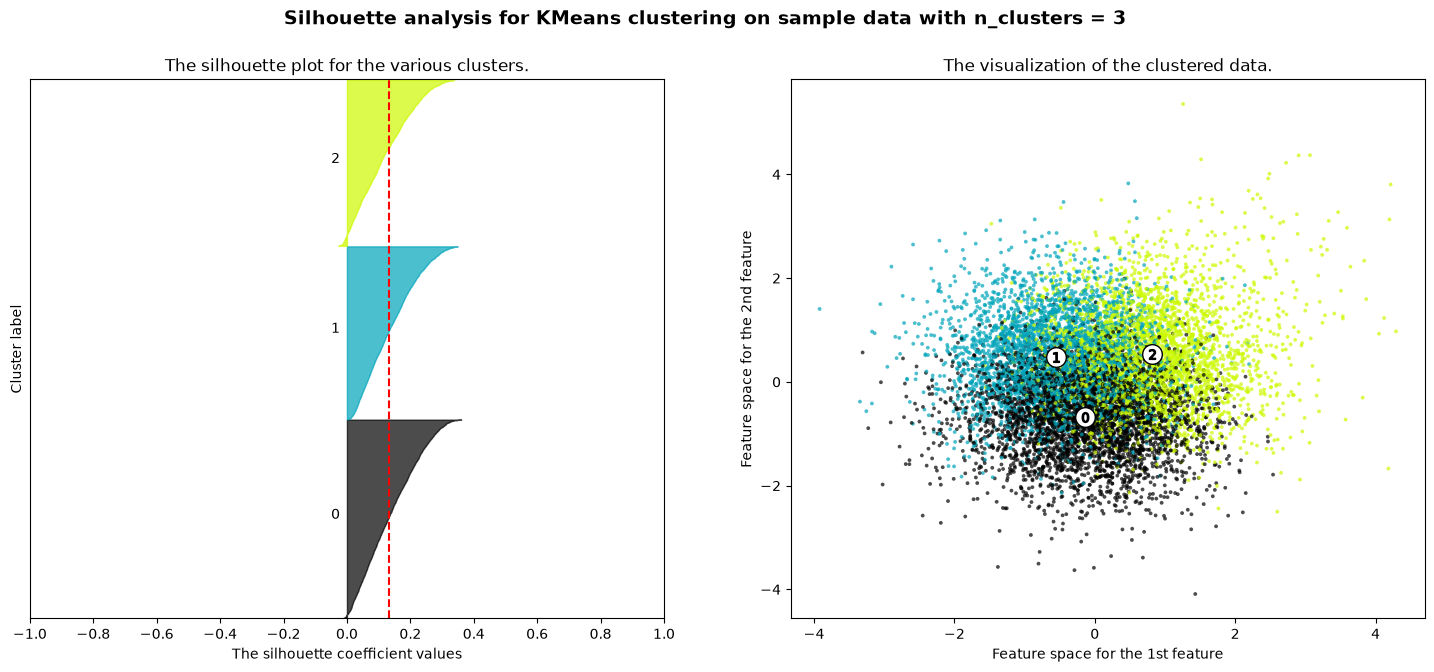

For n_clusters = 4 the average silhouette_score is : 0.13070478779287903


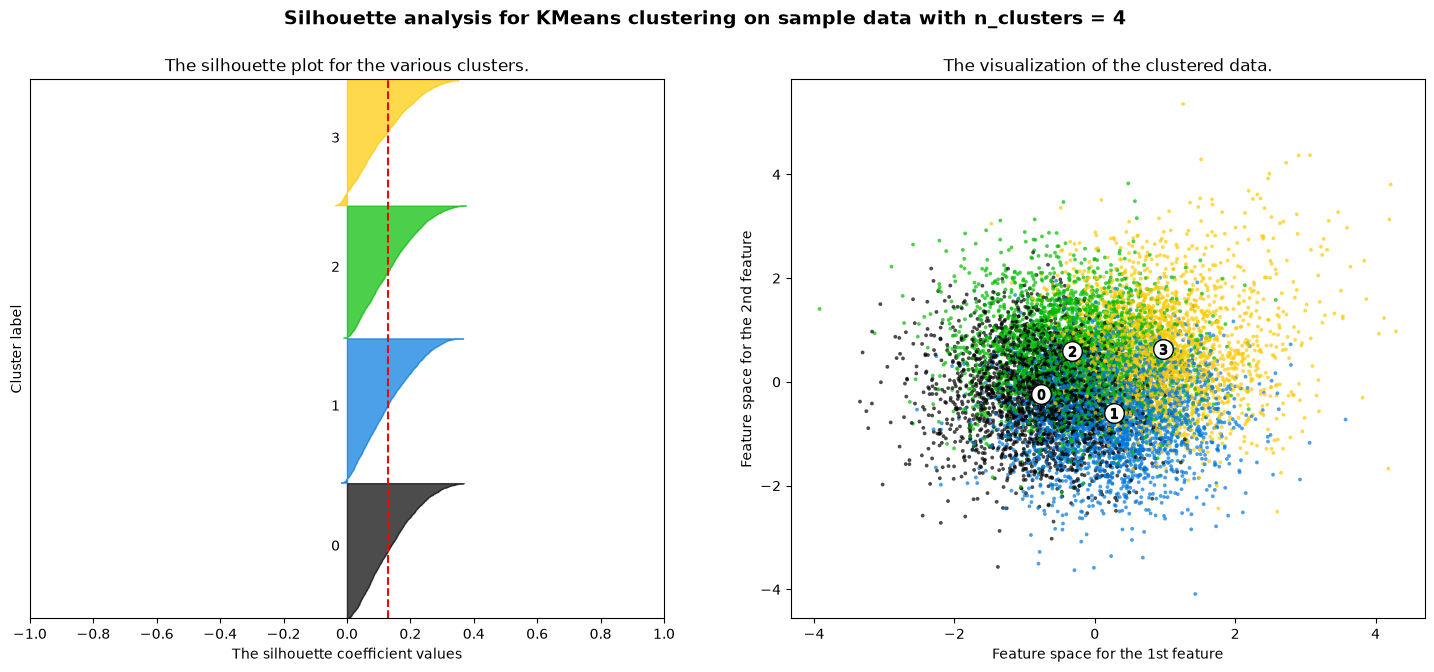

For n_clusters = 5 the average silhouette_score is : 0.13063558066971873


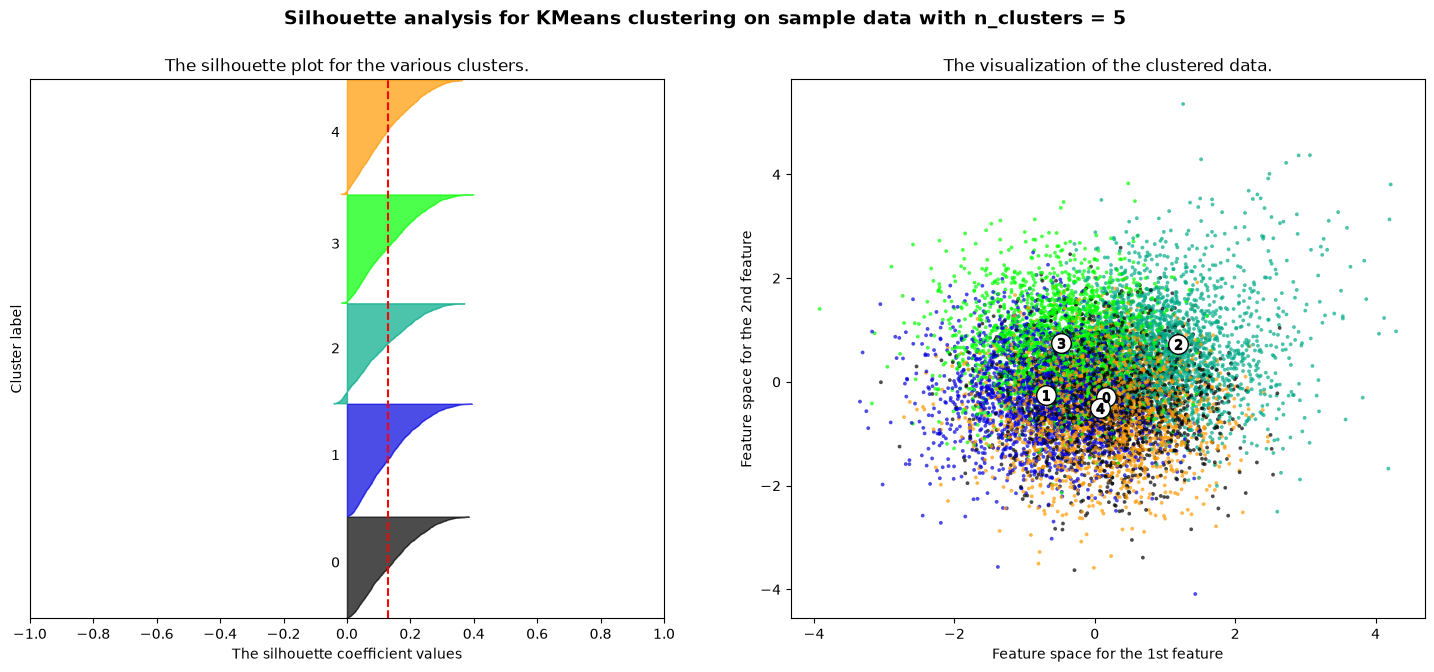

In [39]:
plot_silhouette_and_clusters(df_lineage, range_n_clusters = list(range(2,6)), SEED = SEED)

## Clustering Based on Adult Lineage Markers Differentially Expressed by Time

In [40]:
df_lineage = df_pgs[
    ["copd_epithelium_up", 
    "copd_endothelium_up", 
    "copd_mesenchyme_up", 
    "copd_myeloid_up", 
    "copd_lymphoid_up",
    "copd_epithelium_down", 
    "copd_endothelium_down", 
    "copd_mesenchyme_down", 
    "copd_myeloid_down", 
    "copd_lymphoid_down"]
    ]

For n_clusters = 2 the average silhouette_score is : 0.15582350517882415


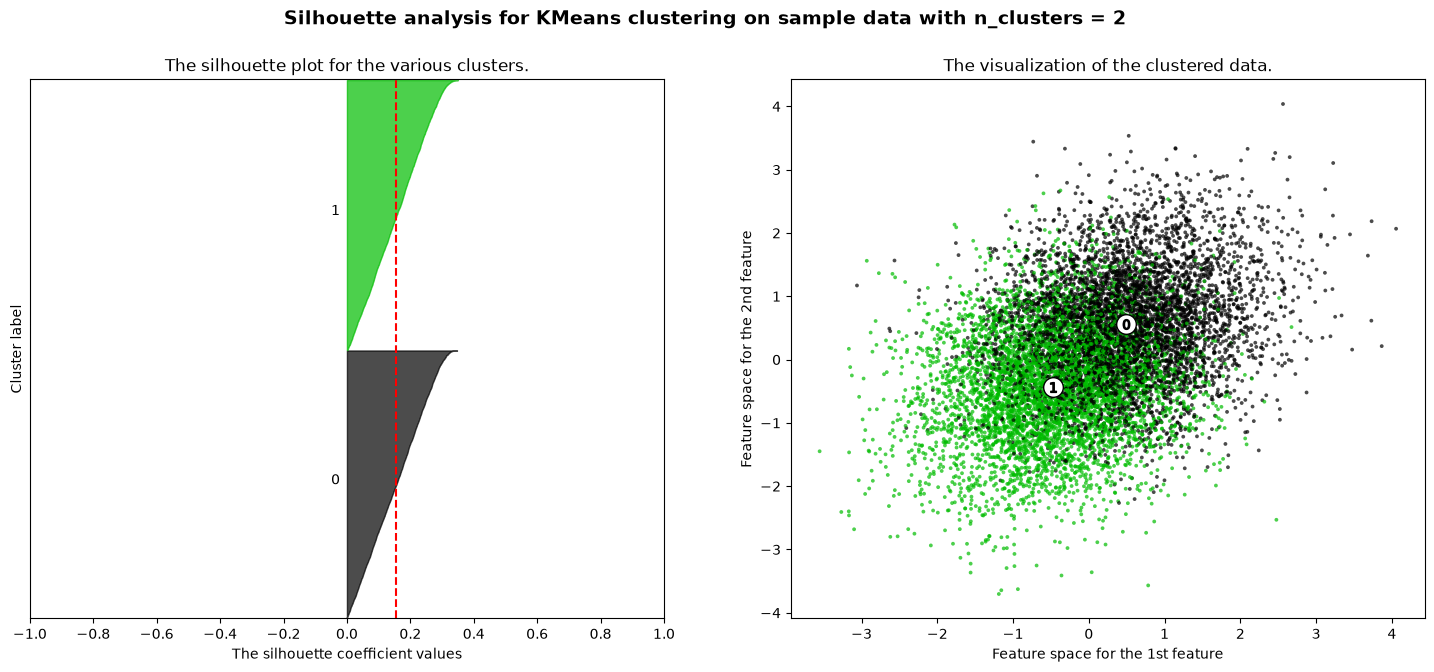

For n_clusters = 3 the average silhouette_score is : 0.10489274808903767


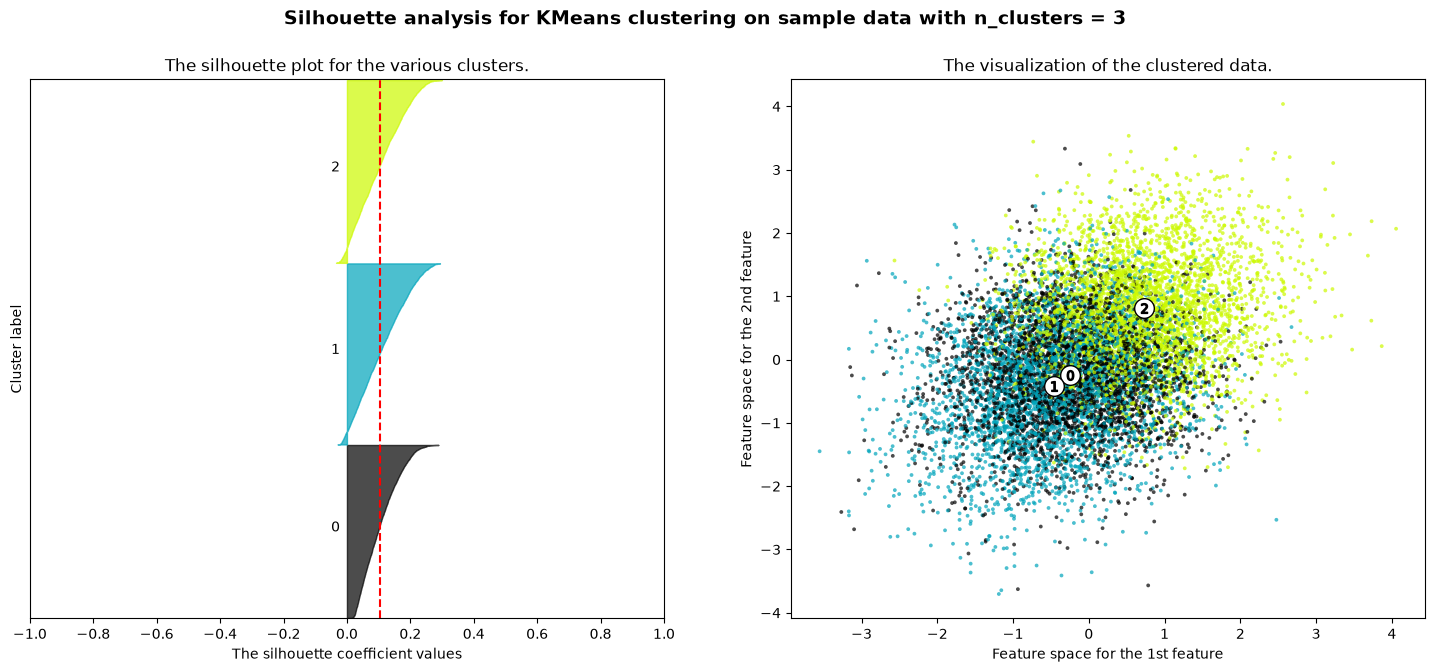

For n_clusters = 4 the average silhouette_score is : 0.09861878690638175


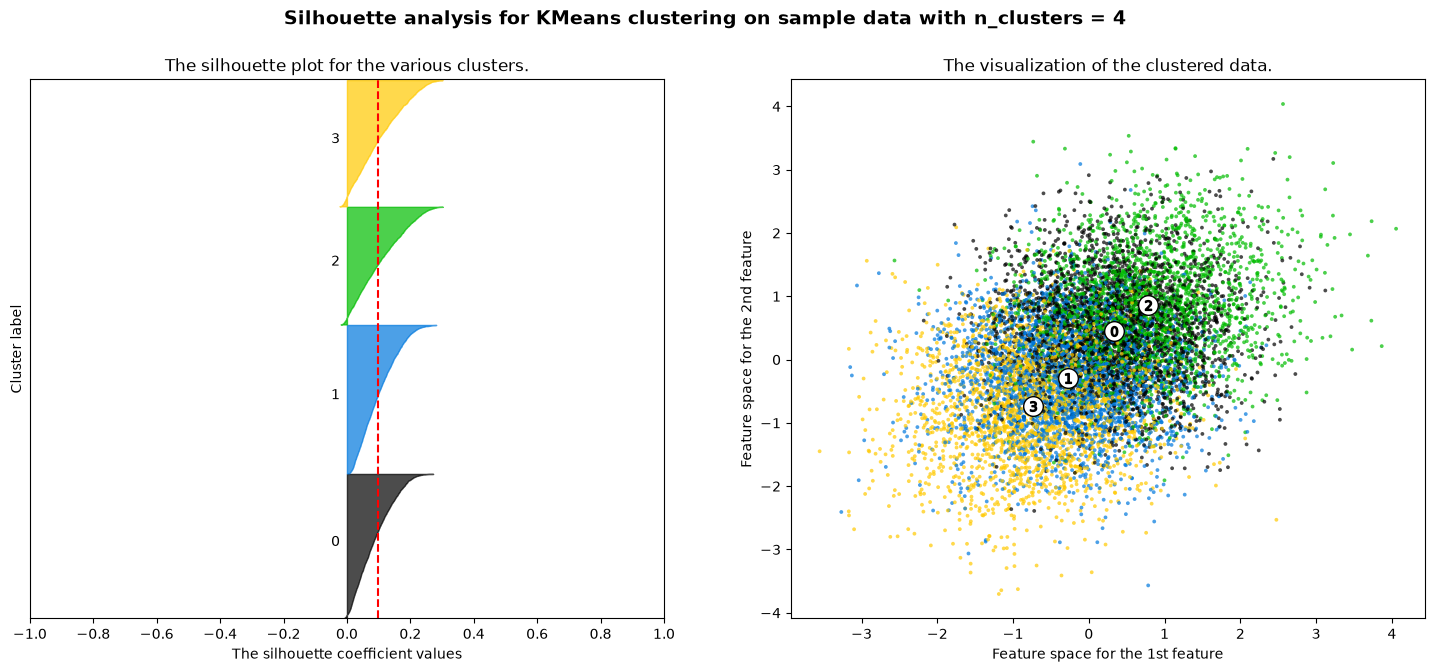

For n_clusters = 5 the average silhouette_score is : 0.08980088547991949


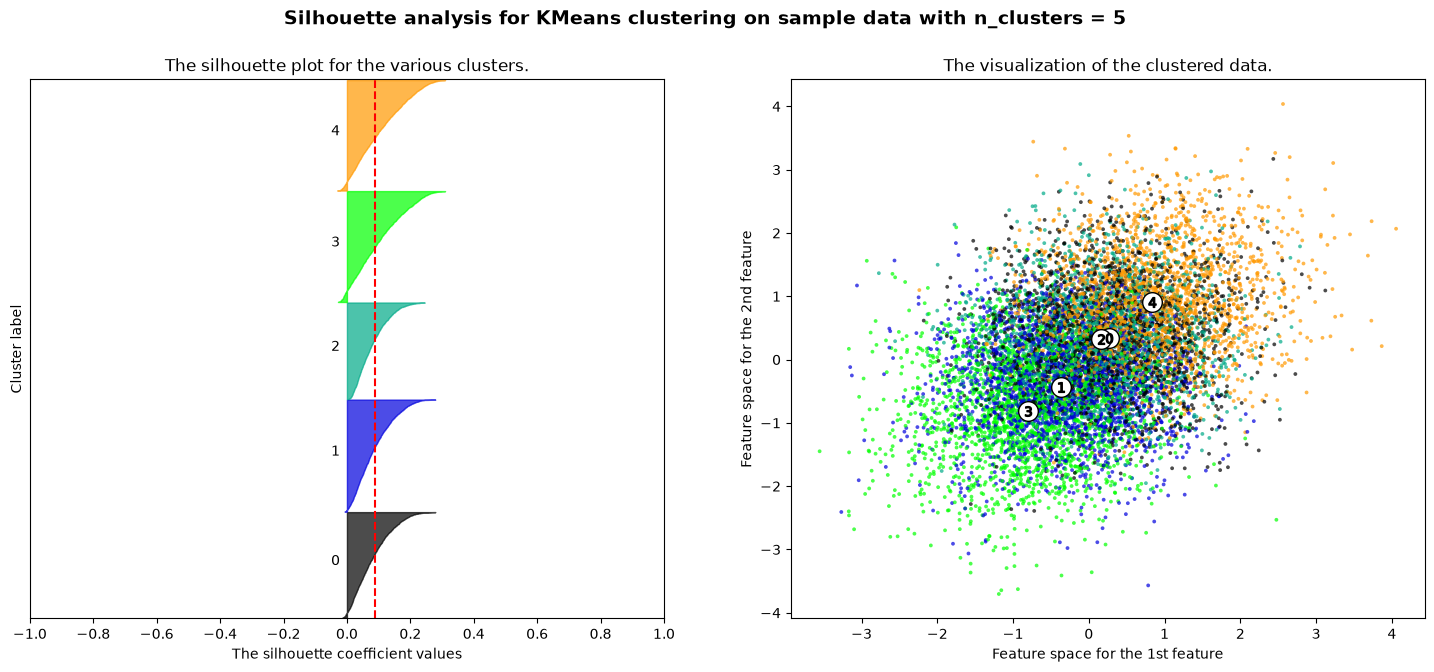

In [41]:
plot_silhouette_and_clusters(df_lineage, range_n_clusters = list(range(2,6)), SEED = SEED)

## Clustering Based on Cell Type Lineage Markers

In [ ]:
df_lineage = df_pgs[
    ['copd_adventitial_fibroblast',
    'copd_aec',
    'copd_alveolar_fibroblast',
    'copd_amac',
    'copd_asmc',
    'copd_at1',
    'copd_at2',
    'copd_basal',
    'copd_cap1', 
    'copd_cap2', 
    'copd_ciliated', 
    'copd_endothelium',
    'copd_epithelium', 
    'copd_myofibroblast',
    'copd_nk',
    'copd_pericyte',
    'copd_ras',
    'copd_secretory', 
    'copd_t_cell',
    'copd_vec',
    'copd_vsmc'
    ]
]

For n_clusters = 2 the average silhouette_score is : 0.11065027125906926


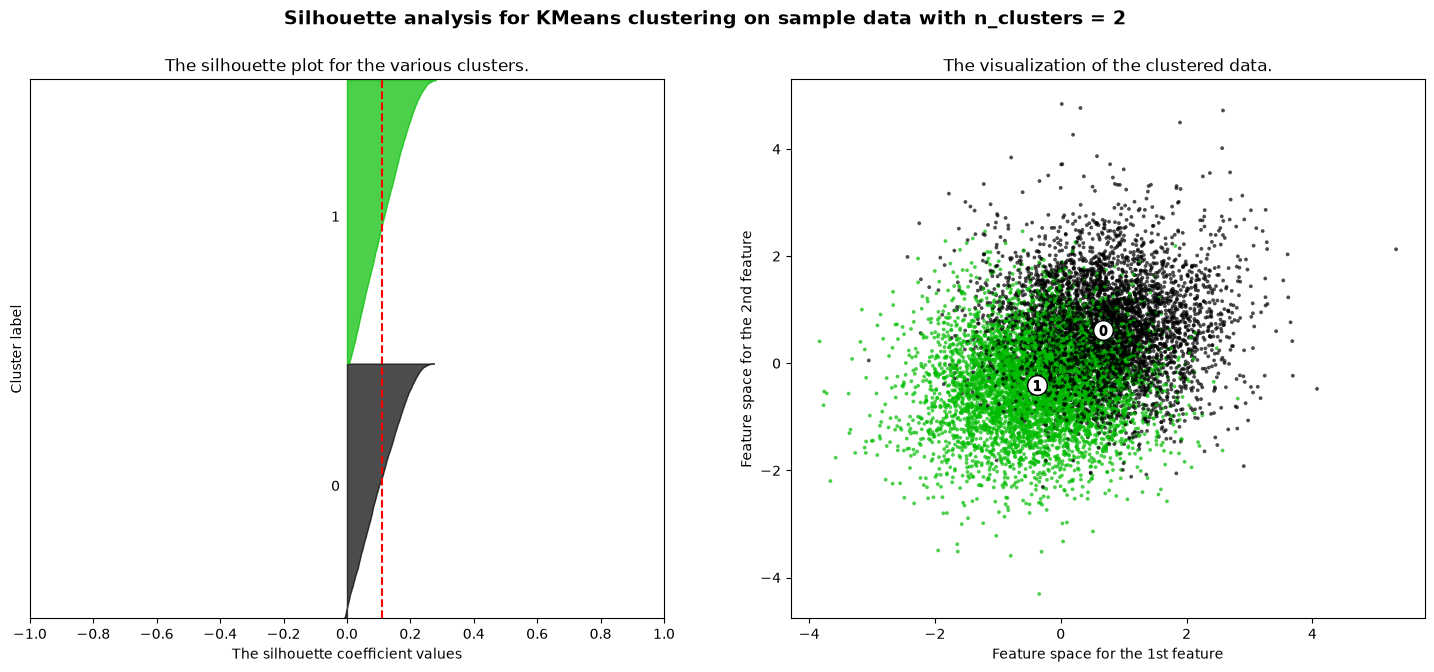

For n_clusters = 3 the average silhouette_score is : 0.07801145670223643


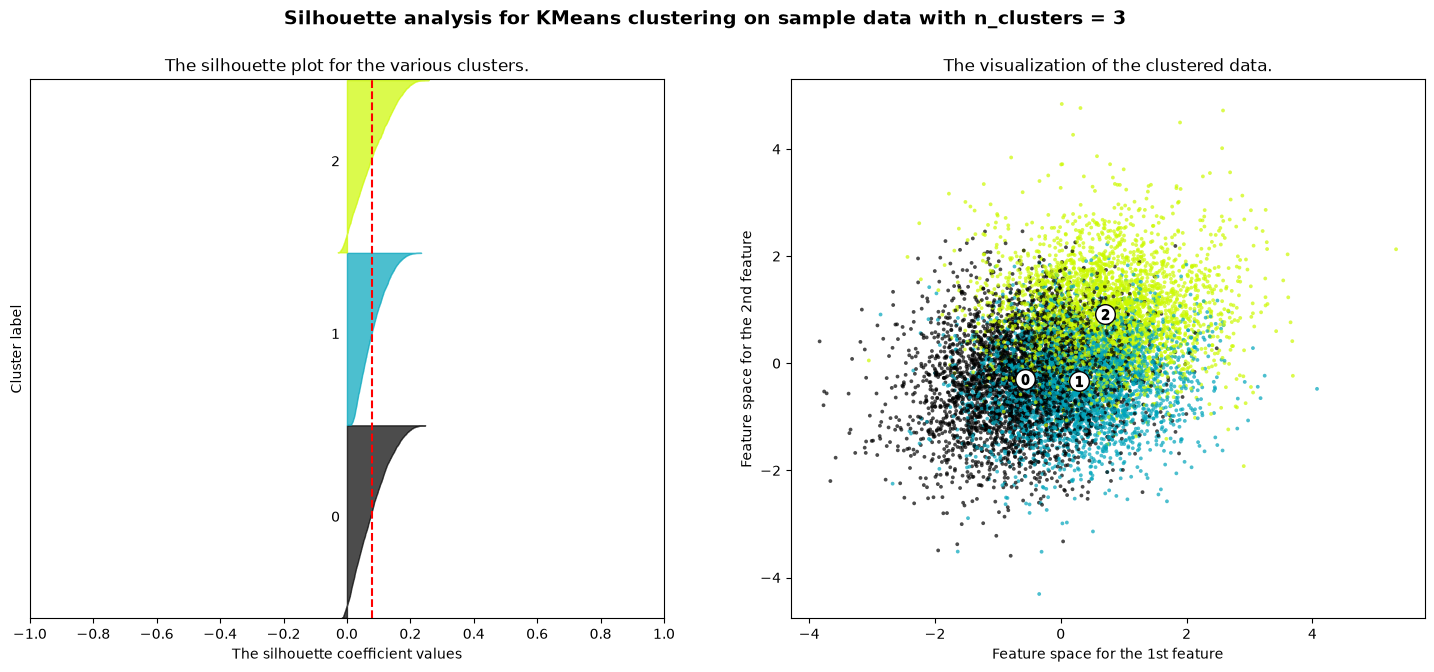

For n_clusters = 4 the average silhouette_score is : 0.06916389261153706


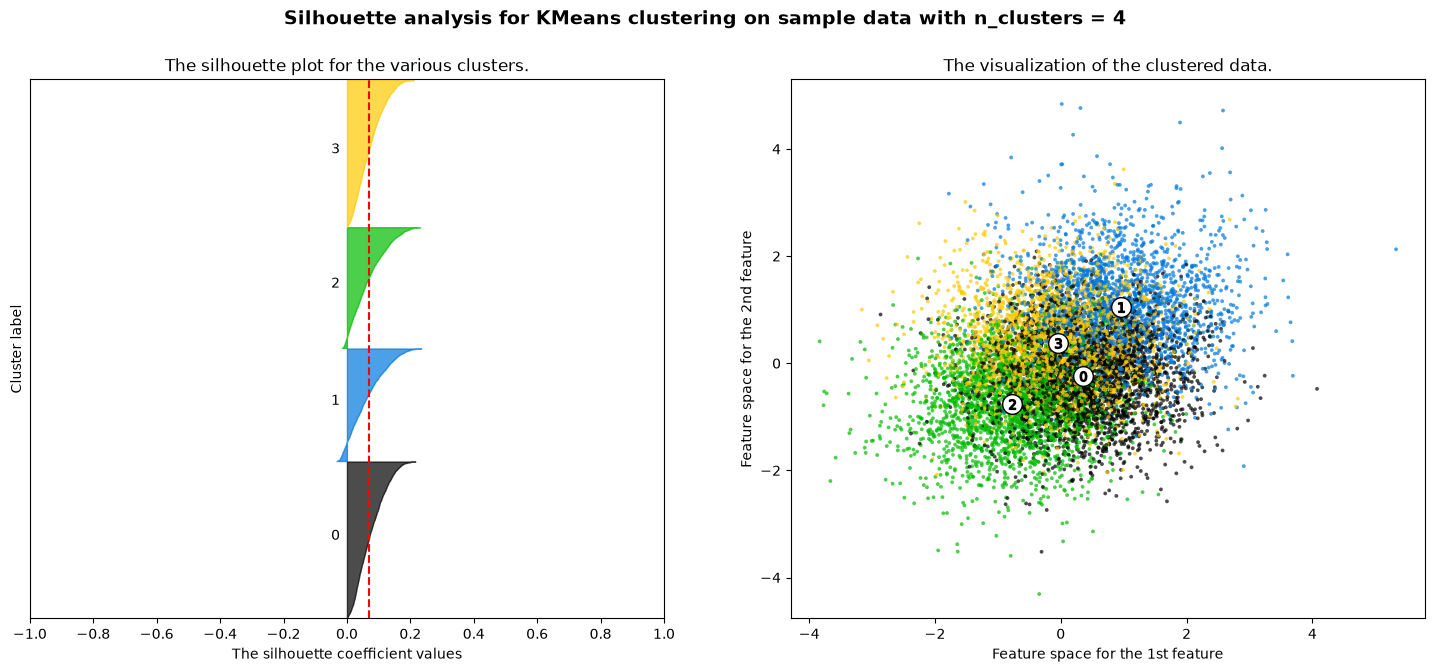

For n_clusters = 5 the average silhouette_score is : 0.06783041170588251


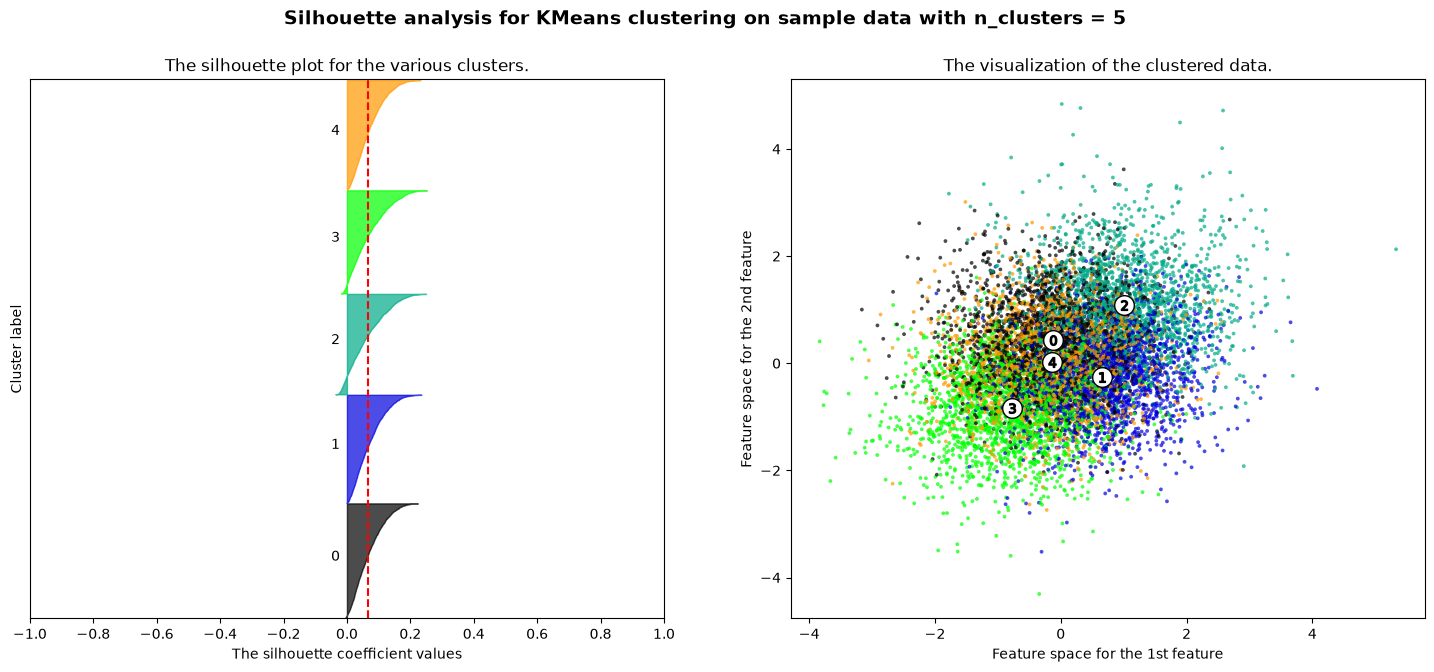

In [44]:
plot_silhouette_and_clusters(df_lineage, range_n_clusters = list(range(2,6)), SEED = SEED)

## Clustering Based on Cell Type Lineage Markers Differentially Expressed by Time

In [2]:
df_lineage = df_pgs[
    ['copd_adventitial_fibroblast_down',
    'copd_adventitial_fibroblast_up', 
    'copd_aec_down',
    'copd_aec_up', 
    'copd_alveolar_fibroblast_down',
    'copd_alveolar_fibroblast_up',
    'copd_amac_down', 
    'copd_amac_up', 
    'copd_asmc_down', 
    'copd_asmc_up', 
    'copd_at1_down',
    'copd_at1_up', 
    'copd_at2_down', 
    'copd_at2_up', 
    'copd_basal_down', 
    'copd_basal_up', 
    'copd_cap1_down',
    'copd_cap1_up', 
    'copd_cap2_down', 
    'copd_cap2_up',
    'copd_ciliated_down',
    'copd_ciliated_up', 
    'copd_endothelium_down',
    'copd_endothelium_up', 
    'copd_epithelium_down',
    'copd_epithelium_up', 
    'copd_lec_down', 
    'copd_lec_up',
    'copd_myofibroblast_down',
    'copd_myofibroblast_up', 
    'copd_nk_down', 
    'copd_nk_up',
    'copd_pericyte_down', 
    'copd_pericyte_up', 
    'copd_ras_down', 
    'copd_ras_up', 
    'copd_sec_down', 
    'copd_sec_up',
    'copd_t_cell_down', 
    'copd_t_cell_up',
    'copd_vec_down', 
    'copd_vec_up', 
    'copd_vsmc_down', 
    'copd_vsmc_up'
    ]
]


NameError: name 'df_pgs' is not defined

In [1]:
def plot_spectral_and_clusters(df, SEED: int, range_n_clusters=list(range(2,12))):
    for n_clusters in range_n_clusters:
        # Create a subplot with 1 row and 2 columns
        fig, (ax1, ax2) = plt.subplots(1, 2)
        fig.set_size_inches(18, 7)

        # The 1st subplot is the silhouette plot
        ax1.set_xlim([-1, 1])
        # The (n_clusters+1)*10 is for inserting blank space between silhouette
        # plots of individual clusters, to demarcate them clearly.
        ax1.set_ylim([0, len(df) + (n_clusters + 1) * 10])
        
        # Create clusterer
        sc = SpectralClustering(n_clusters=n_clusters, random_state=SEED, assign_labels='kmeans', n_init=10)
        labels = sc.fit_predict(df)
        silhouette_avg = silhouette_score(df, labels)
        print(f"Spectral: For n_clusters = {n_clusters} the average silhouette_score is : {silhouette_avg}")

        # Compute the silhouette scores for each sample
        sample_silhouette_values = silhouette_samples(df, labels)

        y_lower = 10
        for i in range(n_clusters):
            # Aggregate the silhouette scores for samples belonging to
            # cluster i, and sort them
            ith_cluster_silhouette_values = \
                sample_silhouette_values[labels == i]

            ith_cluster_silhouette_values.sort()

            size_cluster_i = ith_cluster_silhouette_values.shape[0]
            y_upper = y_lower + size_cluster_i

            color = cm.nipy_spectral(float(i) / n_clusters)
            ax1.fill_betweenx(np.arange(y_lower, y_upper),
                            0, ith_cluster_silhouette_values,
                            facecolor=color, edgecolor=color, alpha=0.7)

            # Label the silhouette plots with their cluster numbers at the middle
            ax1.text(-0.05, y_lower + 0.5 * size_cluster_i, str(i))

            # Compute the new y_lower for next plot
            y_lower = y_upper + 10  # 10 for the 0 samples

        ax1.set_title("The silhouette plot for the various clusters.")
        ax1.set_xlabel("The silhouette coefficient values")
        ax1.set_ylabel("Cluster label")

        # The vertical line for average silhouette score of all the values
        ax1.axvline(x=silhouette_avg, color="red", linestyle="--")

        ax1.set_yticks([])  # Clear the yaxis labels / ticks
        ax1.set_xticks([-1, -0.8, -0.6, -0.4, -0.2, 0, 0.2, 0.4, 0.6, 0.8, 1])

        # 2nd Plot showing the actual clusters formed
        colors = cm.nipy_spectral(labels.astype(float) / n_clusters)
        ax2.scatter(df.iloc[:, 0], df.iloc[:, 1], marker='.', s=30, lw=0, alpha=0.7, c=colors, edgecolor='k')

        # Labeling the clusters
        centers = labels.cluster_centers_
        # Draw white circles at cluster centers
        ax2.scatter(centers[:, 0], centers[:, 1], marker='o',
                    c="white", alpha=1, s=200, edgecolor='k')

        for i, c in enumerate(centers):
            ax2.scatter(c[0], c[1], marker='$%d$' % i, alpha=1,
                        s=50, edgecolor='k')

        ax2.set_title("The visualization of the clustered data.")
        ax2.set_xlabel("Feature space for the 1st feature")
        ax2.set_ylabel("Feature space for the 2nd feature")

        plt.suptitle((f"Silhouette analysis for KMeans clustering on sample data with n_clusters = {n_clusters}"),
                    fontsize=14, fontweight='bold')

        plt.show()